In [20]:
from sklearn.mixture import GaussianMixture
import seaborn as sns
import matplotlib.pyplot as plt
import vtk
import numpy as np
import glob
import sys
import os
import pandas as pd
import diptest
from vtk.util.numpy_support import vtk_to_numpy, numpy_to_vtk

sys.path.append(os.path.pardir)
from utilities import ReadVTUFile, ThresholdInBetween, ThresholdByUpper, LargestConnectedRegion, WriteVTUFile, ReadVTKFile


In [3]:
path = "/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy"
metadata = glob.glob(f"{path}/*.xlsx")
print(metadata)
VTUFiles = sorted(glob.glob(f"{path}/*.vtu"))
TerritoryLabels = sorted(glob.glob(f"{path}/*.dat"))
print(VTUFiles)

PatientMetadata = pd.read_excel(metadata[1], dtype={'column_name': str})

nr_path = '/Volumes/T7_Research/CABG/05_PrePostCABG/NonRegistered'
VTKFiles = sorted(glob.glob(f"{nr_path}/*.vtk"))

['/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/~$PatientMetadata.xlsx', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/PatientMetadata.xlsx']
['/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU04A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU04B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU06A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU06B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU07A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU07B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU10A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostC

In [4]:
patient_ids = sorted(set(PatientMetadata["patient-id"]))
print(patient_ids)

['SU03', 'SU04', 'SU06', 'SU07', 'SU10', 'SU11', 'SU13', 'SU14', 'SU16', 'SU21', 'SU23', 'SU24', 'SU25', 'SU26', 'SU27', 'SU28', 'SU30', 'SU33', 'SU34', 'VA02', 'VA04', 'VA06', 'VA08', 'VA10', 'VA13', 'VA14', 'VA16', 'VA20']


In [35]:
def GetScalarArrayName (Data):
    for i in range(Data.GetPointData().GetNumberOfArrays()):
        array_name_ = Data.GetPointData().GetArrayName(i)
        if 'scalar' in array_name_.lower():
            return array_name_
        
def DipTest(array):
    dip, pval = diptest.diptest(np.sort(array.flatten()))
    if pval < 0.05:
        print("The distribution is likely bimodal/multimodal.")
    else:
        print("The distribution is likely unimodal.")

<class 'numpy.ndarray'>
5828537.884324838
5828434.233480976
The distribution is likely bimodal/multimodal.


/Users/anaseresti/miniconda3/envs/Perfusion/lib/python3.9/site-packages/diptest/consts.py:702: UserWarning: Sample size exceeds the maximum limit of 72000. Results may not be accurate with precomputed statistical values.
  warnings.warn(


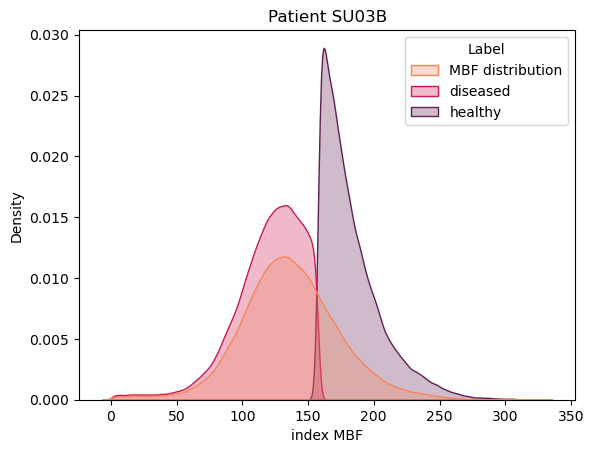

In [36]:
patient_id = 'SU03'

VTKFiles = np.array(VTKFiles)
out = np.where(np.char.find(VTKFiles, patient_id+'B') !=-1)
MBF_B_unregistered = ReadVTKFile(VTKFiles[out].item())

ScalaraArrayName = GetScalarArrayName(MBF_B_unregistered)
MBF_B_array = vtk_to_numpy(MBF_B_unregistered.GetPointData().GetArray(ScalaraArrayName))
MBF_B_array = MBF_B_array[MBF_B_array > 0]
print(type(MBF_B_array))

array = MBF_B_array.reshape(-1,1)

gmm2 = GaussianMixture(n_components=2).fit(array)
labels = gmm2.predict(array)

gmm1 = GaussianMixture(n_components=1).fit(array)

diseased = MBF_B_array[labels == 0]
healthy = MBF_B_array[labels == 1]

if gmm2.bic(array) < gmm1.bic(array):
    print("The distribution is likely bimodal")

print(gmm2.bic(array))
print(gmm1.bic(array))

DipTest(array)


df = pd.DataFrame({
    'MBF':np.concatenate([MBF_B_array, diseased, healthy]),
    'Label': ['MBF distribution'] * len(MBF_B_array) +
             ['diseased'] * len(diseased) +
             ['healthy'] * len(healthy)
})

plt.figure()
sns.kdeplot(data=df, x="MBF", hue='Label',
                fill=True, common_norm=False, palette="rocket_r",
            alpha=.3, linewidth=1)
plt.xlabel('index MBF')
plt.title(f"Patient {patient_id}B")
#plt.xlim((0, 2))
plt.show()

The distribution is likely bimodal


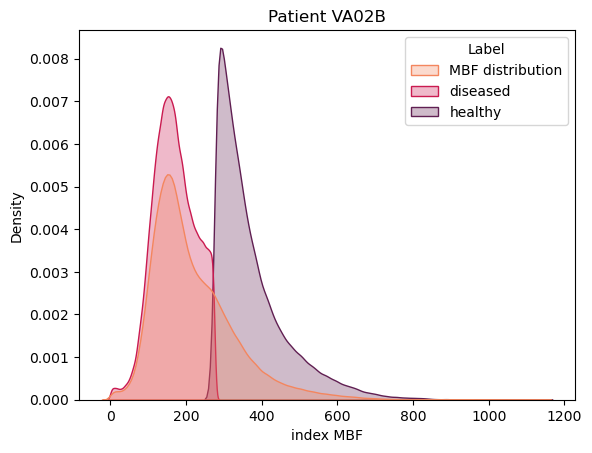

In [ ]:
out = np.where(np.char.find(VTKFiles, patient_id+'A') !=-1)
MBF_A_unregistered = ReadVTKFile(VTKFiles[out].item())

ScalaraArrayName = GetScalarArrayName(MBF_A_unregistered)
MBF_A_array = vtk_to_numpy(MBF_A_unregistered.GetPointData().GetArray(ScalaraArrayName))
MBF_A_array = MBF_A_array[MBF_A_array > 0]

array = MBF_A_array.reshape(-1,1)

gmm2 = GaussianMixture(n_components=2).fit(array)
labels = gmm2.predict(array)

gmm1 = GaussianMixture(n_components=1).fit(array)

diseased = MBF_A_array[labels == 0]
healthy = MBF_A_array[labels == 1]

if gmm2.bic(array) < gmm1.bic(array):
    print("The distribution is likely bimodal")

diseased = MBF_A_array[labels == 0]
healthy = MBF_A_array[labels == 1]

df = pd.DataFrame({
    'MBF':np.concatenate([MBF_A_array, diseased, healthy]),
    'Label': ['MBF distribution'] * len(MBF_A_array) +
             ['diseased'] * len(diseased) +
             ['healthy'] * len(healthy)
})

plt.figure()
sns.kdeplot(data=df, x="MBF", hue='Label',
                fill=True, common_norm=False, palette="rocket_r",
            alpha=.3, linewidth=1)
plt.xlabel('index MBF')
plt.title(f"Patient {patient_id}A")
#plt.xlim((0, 2))
plt.show()

In [ ]:
Removed_Cases = ["SU25", "VA04"]

stats = []
for patient_id in patient_ids:
    if patient_id in Removed_Cases: 
        continue
    print(patient_id)
    VTKFiles = np.array(VTKFiles)
    out = np.where(np.char.find(VTKFiles, patient_id+'B') !=-1)
    MBF_B_unregistered = ReadVTKFile(VTKFiles[out].item())

    ScalaraArrayName = GetScalarArrayName(MBF_B_unregistered)
    MBF_B_array = vtk_to_numpy(MBF_B_unregistered.GetPointData().GetArray(ScalaraArrayName))
    MBF_B_array = MBF_B_array[MBF_B_array > 0]
    index_MBF_B = MBF_B_array/np.percentile(MBF_B_array, 75)

    out = np.where(np.char.find(VTKFiles, patient_id+'A') !=-1)
    MBF_A_unregistered = ReadVTKFile(VTKFiles[out].item())

    ScalaraArrayName = GetScalarArrayName(MBF_A_unregistered)
    MBF_A_array = vtk_to_numpy(MBF_A_unregistered.GetPointData().GetArray(ScalaraArrayName))
    MBF_A_array = MBF_A_array[MBF_A_array > 0]
    index_MBF_A = MBF_A_array/np.percentile(MBF_A_array, 75)

    stats.append({'case': patient_id, 'median_A': np.median(index_MBF_A), 'median_B': np.median(index_MBF_B), 'is_ischemic':False})

    df = pd.DataFrame({
        'MBF':np.concatenate([index_MBF_A, index_MBF_B]),
        'Label': ['raw baseline MBF'] * len(MBF_A_array) +
                ['raw follow-up MBF'] * len(MBF_B_array)
    })

    plt.figure()
    sns.kdeplot(data=df, x="MBF", hue='Label',
                    fill=True, common_norm=False, palette="rocket_r",
                alpha=.3, linewidth=1, clip=(0, 2))
    plt.xlabel('index MBF')
    plt.title(f"Patient {patient_id}")
    plt.xlim((0, 2))
    plt.show()


## Pipeline

 - Check if the Pre-CABG distribution is unimodal or bimodal.
 - For unimodal cases use z-score to check if the median falls below or above zero for diseased or healthy MBF distributions.
 - For bimodal distributions, find the two healthy and diseased clusters, use the healthy clusters as remote regions for perfusion drop calculations.

In [13]:
def CollectMBFData(MBF, Labels):
    for i in range(MBF.GetPointData().GetNumberOfArrays()):
            arrayname_ = MBF.GetPointData().GetArrayName(i)
            if 'scalars' in arrayname_.lower():
                ScalarArray = arrayname_

    AbsMBFData = {}
    IndexMBFData = {}
    for key in Labels.keys():
        AbsMBFData[key] = np.array([])
        IndexMBFData[key] = np.array([])
        for i in Labels[key]:
            territory_ = ThresholdInBetween(MBF, "TerritoryMaps", i, i)
            MBF_ = vtk_to_numpy(territory_.GetPointData().GetArray(ScalarArray))
            iMBF_ = vtk_to_numpy(territory_.GetPointData().GetArray("IndexMBF"))
            AbsMBFData[key] = np.append(AbsMBFData[key], MBF_)
            IndexMBFData[key] = np.append(IndexMBFData[key], iMBF_)


def ReadLabels(InputLabels, TerritoryTag):
    MBF_Labels = {}
    for tag in TerritoryTag:
        MBF_Labels[tag] =  []
    MBF_Labels["Non-grafted\nstenosis>50%"] = []
    MBF_Labels["Non-grafted\nstenosis<50%"] = []
    with open(InputLabels, "r") as ifile:
        for i, LINE in enumerate(ifile):
            if i == 0: 
                continue
            line = LINE.strip().split()
            label = line[1]
            id_value = int(line[0])
            found = False

            for key in TerritoryTag:
                if key in label: 
                    MBF_Labels[key].append(id_value)
                    found = True
            
            if not found:
                if "NG" in label:
                    MBF_Labels["Non-grafted\nstenosis>50%"].append(id_value)
                    found = True
                else:
                    MBF_Labels["Non-grafted\nstenosis<50%"].append(id_value)

    MBF_Labels = {k.replace('post_', ''):v for k,v in MBF_Labels.items() if len(v)>0}
    
    return MBF_Labels

def MapNongrafted(meanA, meanB, stdA, stdB, DataA):
    return meanB + (stdB/stdA)*(DataA - meanA)


def WilcoxonTest(array1, array2):
    w_value, p_value = wilcoxon(array1, array2)
    print("Wilcoxon test statistics: ", w_value)
    print("p-value: ", p_value)
    print("number of datapoints:", len(array1))

    if p_value < 0.05:
        print("Reject the null hypothesis: There is a significant difference between the two samples.")
    else:
        print("Fail to reject the null hypothesis: There is no significant difference between the two samples.")

    return p_value

In [14]:
path = "/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy"
opath = os.path.join(path,"MappedPreCABG")
os.system(f"mkdir {opath}")
metadata = glob.glob(f"{path}/*.xlsx")
print(metadata)
VTUFiles = sorted(glob.glob(f"{path}/*.vtu"))
TerritoryLabels = sorted(glob.glob(f"{path}/*.dat"))
print(VTUFiles)

PatientMetadata = pd.read_excel(metadata[1], dtype={'column_name': str})

mkdir: /Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/MappedPreCABG: File exists


['/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/~$PatientMetadata.xlsx', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/PatientMetadata.xlsx']
['/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU03B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU04A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU04B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU06A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU06B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU07A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU07B_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostCABG/InterPatientStudy/SU10A_MBF_Territories.vtu', '/Volumes/T7_Research/CABG/05_PrePostC

In [ ]:
for patient_id in patient_ids:
    print(patient_id)
    tags = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['stenosis tag'])
    ischemia = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['is-ischemic'])
    TerritoryTags = [f'post_{tag}' for tag in tags]
    cutoff = list(PatientMetadata[PatientMetadata['patient-id'] == patient_id]['cutoff'])[0]
    if cutoff == 0:
        cutoff = 142
    for file in TerritoryLabels:
        if patient_id in os.path.basename(os.path.splitext(file)[0]):
            LabelFile = file
    MBF_Labels = ReadLabels(LabelFile, TerritoryTags)
    normalization_method = "zscore"
    for file in VTUFiles:
        if f"{patient_id}A" in os.path.basename(os.path.splitext(file)[0]):
            MBF_A = ReadVTUFile(file)
        elif f"{patient_id}B" in os.path.basename(os.path.splitext(file)[0]):
            MBF_B = Normalize(ReadVTUFile(file), normalization_method, cutoff/2)
    AbsMBFData_A, IndexMBFData_A = CollectMBFData(MBF_A, MBF_Labels)
    AbsMBFData_B, IndexMBFData_B = CollectMBFData(MBF_B, MBF_Labels)
    data = pd.DataFrame({"MBF": [], "Territories": [], "Type": []})
    dataMapped = pd.DataFrame({"MBF": [], "Territories": [], "Type": []})
    t = "Non-grafted\nstenosis<50%"
    array_A = AbsMBFData_A[t]
    mean_A = np.mean(array_A)
    std_A = np.std(array_A)
    array_B = AbsMBFData_B[t]
    mean_B = np.mean(array_B)
    std_B = np.std(array_B)
    MBF_A_mapped = Map3DVolume(mean_A, mean_B, std_A, std_B, MBF_A)
    WriteVTUFile(os.path.join(opath,f"{patient_id}A_MBF_Mapped.vtu"), MBF_A_mapped)
    WriteVTUFile(os.path.join(opath,f"{patient_id}B_MBF_Mapped.vtu"), MBF_B)
    #data_ = pd.DataFrame({"MBF": np.concatenate([array_A, array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['A']*len(array_A) + ['B']*len(array_B)})
    #data = pd.concat([data, data_], ignore_index=True)
    # Mapping
    #data_mapped_ = pd.DataFrame({"MBF": np.concatenate([MapNongrafted(mean_A, mean_B, std_A, std_B, array_A), array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['A']*len(array_A) + ['B']*len(array_B)})
    #dataMapped = pd.concat([dataMapped, data_mapped_], ignore_index=True)
    for i, t in enumerate(tags):
        array_A = AbsMBFData_A[t]
        array_B = AbsMBFData_B[t]
        data_ = pd.DataFrame({"MBF": np.concatenate([array_A, array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
        data = pd.concat([data, data_], ignore_index=True)
        # Mapping
        data_mapped_ = pd.DataFrame({"MBF": np.concatenate([MapNongrafted(mean_A, mean_B, std_A, std_B, array_A), array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
        dataMapped = pd.concat([dataMapped, data_mapped_], ignore_index=True)
    t = "Non-grafted\nstenosis>50%"
    if t in MBF_Labels.keys():
        array_A = AbsMBFData_A[t]
        array_B = AbsMBFData_B[t]
        data_ = pd.DataFrame({"MBF": np.concatenate([array_A, array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
        data = pd.concat([data, data_], ignore_index=True)
        # Mapping
        data_mapped_ = pd.DataFrame({"MBF": np.concatenate([MapNongrafted(mean_A, mean_B, std_A, std_B, array_A), array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
        dataMapped = pd.concat([dataMapped, data_mapped_], ignore_index=True)
    t = "Non-grafted\nstenosis<50%"
    array_A = AbsMBFData_A[t]
    array_B = AbsMBFData_B[t]
    data_ = pd.DataFrame({"MBF": np.concatenate([array_A, array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
    data = pd.concat([data, data_], ignore_index=True)
    # Mapping
    data_mapped_ = pd.DataFrame({"MBF": np.concatenate([MapNongrafted(mean_A, mean_B, std_A, std_B, array_A), array_B]), "Territories": [t]*len(array_A) + [t]*len(array_B), "Type": ['Baseline']*len(array_A) + ['Follow-up']*len(array_B)})
    dataMapped = pd.concat([dataMapped, data_mapped_], ignore_index=True)
    
    
    #BoxPlot(data)
    ViolinPlot(data)
    #print("--- Mapping Results:")
    ViolinPlot(dataMapped)


SU03


NameError: name 'Normalize' is not defined